# 03 — Phase 3: Stationarity and Structural-Break Testing

## Inflation Prediction and Economic Signal Analysis: A Multi-Country Time-Series Study

**Phase 3 Deliverable** · **Reusable testing modules in `src/stationarity.py` and `src/structural_breaks.py`** · **Decision log D-024 through D-033 in `ProjectDriven.md`**

---

## Executive Summary

This notebook operationalises the ten Phase 3 design decisions that transform the four analysis-ready datasets produced by Phase 2 into Phase-6-ready inputs, and that characterise the structural breaks at three pre-specified dates (2008-09, 2020-03, 2022-02) through both known-break Chow tests and data-driven Quandt-Andrews sup-Wald scans.

**Two tasks executed in sequence:**

1. **Task 1 — Stationarity testing.** ADF and KPSS applied jointly under a four-quadrant protocol (D-024) to 20 series at their level form, then to 13 flagged series after first-differencing. A per-(country × indicator) Transformation Registry (D-027, D-031) records the form to be used as Phase 6 VAR input, with per-country CPI specifications determined by the Step 3 deep-dive.

2. **Task 2 — Structural-break testing.** Three Chow variants (classical, HAC-Wald, HAC-Wald with COVID dummy) applied at each of the three pre-specified dates. Per-coefficient decomposition isolates the economic channel driving each detected break. Quandt-Andrews sup-Wald scan at two trim fractions (π₀ = 0.15 and π₀ = 0.10) then independently detects the most probable break date from the data alone.

**Signature findings (four interwoven stories):**

- **Statistical robustness.** Classical vs HAC Chow agree 12/12 on reject/non-reject; HAC vs COVID-dummy HAC agree 8/8. Autocorrelation, heteroskedasticity, and COVID outliers do not drive the conclusions.
- **GFC_2008 is USA-specific.** Only USA rejects at α = 0.05 at the GFC break. Japan, UK, and Germany show p-values between 0.06 and 0.53, consistent with differential ECB/BOJ liquidity responses.
- **Break channel differs by country at the same date.** At ENERGY_2022, the dominant regressor is POLICY_RATE for USA (z = +5.95), the constant for Japan (z = +4.98), GDP for UK (z = +3.58), and GDP for Germany (z = +2.82). The same calendar event operated through different economic channels in different economies.
- **Data-driven detection confirms the ex-ante specification.** Quandt-Andrews argmax at π₀ = 0.10 falls within ±1 month of 2022-02 (ENERGY break) for all four countries. USA sup-W = 37.73 exceeds the Andrews 1% critical value (23.04). The data independently pinpoint the break date that ProjectScope identified from economic reasoning alone.

**Decision coverage:**

| ID | Scope | Short description |
|---|---|---|
| D-024 | Task 1 | ADF + KPSS four-quadrant joint protocol |
| D-025 | Task 1 | Variable-specific ADF regression specification |
| D-026 | Task 1 | AIC lag selection with Schwert (1989) max |
| D-027 | Task 1 | Transformation Registry (Phase 6 + Chow inputs) |
| D-028 | Task 2 | Per-country stationary CPI as Chow dependent |
| D-029 | Task 2 | COVID-dummy Chow as robustness variant |
| D-030 | Task 2→6 | Phase 6 regime-dummy channel specification |
| D-031 | Task 1 | Japan CPI I(1) acceptance (revised) |
| D-032 | Task 1+2 | `src/` module separation |
| D-033 | Task 2 | Quandt-Andrews π₀ sensitivity |

**Output artefacts:**

```
data/documentation/
├── phase3_adf_kpss_levels.csv                        (20 rows)
├── phase3_differencing_log.csv                       (16 rows)
├── phase3_cpi_deep_dive.csv                          (36 rows)
├── phase3_subperiod_stationarity.csv                 (60 rows)
├── phase3_transformation_registry_final.csv          (20 rows — source of truth)
├── phase3_chow_tests_classical.csv                   (12 rows)
├── phase3_chow_tests_hac.csv                         (12 rows)
├── phase3_chow_tests_covid_dummy.csv                 (8  rows)
├── phase3_chow_coefficient_decomposition.csv         (60 rows)
├── phase3_chow_bonferroni_summary.csv                (32 rows)
├── phase3_quandt_andrews_supwald.csv                 (4  rows — π₀=0.15)
├── phase3_quandt_andrews_curve.csv                   (815 rows — π₀=0.15)
├── phase3_quandt_andrews_supwald_trim10.csv          (4  rows — π₀=0.10)
└── phase3_quandt_andrews_curve_trim10.csv            (933 rows — π₀=0.10)

outputs/figures/
├── phase3_adf_kpss_quadrant.png
├── phase3_transform_before_after.png
├── phase3_subperiod_heatmap.png
├── phase3_cpi_transform_matrix.png
├── phase3_chow_f_heatmap.png
├── phase3_energy2022_forest.png
├── phase3_quandt_andrews_curves.png
└── phase3_argmax_alignment.png
```

All four main-country datasets are now Phase-4-ready with their per-variable transformation decisions finalised and every structural break characterised.

---


## 1. Context and Analytical Pipeline

### 1.1 Motivation

Phase 2 delivered four NaN-free main-country datasets with harmonised units and frequencies. Before any VAR estimation can proceed, two further questions must be answered:

1. **Is each series stationary?** Vector autoregression under non-stationary inputs yields spurious coefficient estimates whose distributions are non-standard. Each of the 20 main-country series must be classified, and non-stationary series must be transformed to a stationary form prior to Phase 6.

2. **Are the model parameters stable across the 25-year analysis window?** Three structural breaks are pre-specified by ProjectScope §9 — the Global Financial Crisis (2008-09), the COVID shock (2020-03), and the Energy / Russia–Ukraine shock (2022-02). If any of these breaks is statistically detected, the VAR specification in Phase 6 must incorporate regime handling (D-030).

These two questions correspond to Task 1 (stationarity) and Task 2 (structural-break testing), respectively, as defined in ProjectScope §9 Phase 3.

### 1.2 Mathematical specification

**Task 1 — Joint stationarity protocol (D-024).**  For each series $\{x_t\}_{t=1}^{T}$, two tests with opposing null hypotheses are applied:

- ADF null $H_0^{\text{ADF}}$: unit root present (non-stationary)
- KPSS null $H_0^{\text{KPSS}}$: series is (trend-)stationary around the chosen deterministic component

At significance level $\alpha = 0.05$:

$$
\text{classification}(x_t) =
\begin{cases}
\text{Stationary}                     & \text{if } p_{\text{ADF}} < \alpha \text{ and } p_{\text{KPSS}} \ge \alpha \\
\text{Non-stationary}                 & \text{if } p_{\text{ADF}} \ge \alpha \text{ and } p_{\text{KPSS}} < \alpha \\
\text{Trend-stationary (conflict)}    & \text{if } p_{\text{ADF}} < \alpha \text{ and } p_{\text{KPSS}} < \alpha \\
\text{Inconclusive}                   & \text{if } p_{\text{ADF}} \ge \alpha \text{ and } p_{\text{KPSS}} \ge \alpha \\
\end{cases}
$$

**Task 2 — Chow test (known break) and Quandt-Andrews sup-Wald (unknown break).**  Let $y_t$ denote the per-country stationary CPI form (D-028) and $X_t$ the four-regressor vector (transformed POLICY_RATE, UNEMPLOYMENT, GDP, M2 per the Registry).  Define the split indicator $D_t(\tau) = \mathbf{1}\{t \ge \tau\}$.  The Wald statistic for a structural break at $\tau$ uses the dummy-interaction regression

$$
y_t \;=\; \alpha + X_t\beta + D_t(\tau)\bigl(\alpha' + X_t\beta'\bigr) + \varepsilon_t
$$

with null $H_0: \alpha' = 0 \text{ and } \beta' = 0$ (a joint restriction on $k = 5$ coefficients when constant + four regressors shift). The Wald statistic is computed under Newey–West HAC covariance with lag 4 (D-029). The Quandt-Andrews sup-Wald scans

$$
\text{sup-}W \;=\; \max_{\tau \in [\pi_0 T,\; (1-\pi_0) T]} W(\tau)
$$

across the Andrews-trimmed interior of the sample and compares against Andrews (1993) Table I critical values at $\pi_0 \in \{0.10, 0.15\}$ (D-033).

### 1.3 Pipeline stages in this notebook

```
data/processed/*.csv
      │
      │ ┌─────────────────────────────────────────────────────────────┐
      ├─┤ Task 1: Stationarity                                         │
      │ │   §3  Level ADF+KPSS   (D-024, D-025, D-026)                 │
      │ │   §3  First-diff re-test                                      │
      │ │   §4  CPI deep-dive + Registry (D-027, D-031)                │
      │ └─────────────────────────────────────────────────────────────┘
      │
      │ ┌─────────────────────────────────────────────────────────────┐
      └─┤ Task 2: Structural breaks                                   │
        │   §5  Chow at {2008-09, 2020-03, 2022-02}  (D-029)           │
        │   §6  Per-coefficient decomposition  (D-030)                 │
        │   §7  Quandt-Andrews sup-Wald  (D-033)                       │
        │   §8  Phase-6 implications                                   │
        └─────────────────────────────────────────────────────────────┘
```

---


## 2. Environment Setup

### 2.1 Imports and path resolution

Phase 3 imports from the two reusable modules introduced in D-032:

- `src.stationarity` — univariate ADF/KPSS + four-quadrant classifier + five transforms.
- `src.structural_breaks` — Chow (classical / HAC / COVID-dummy), per-coefficient decomposition, Quandt-Andrews sup-Wald.

These modules are the single source of truth; this notebook is a thin narrative layer.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Walk up to the project root so `import src` succeeds regardless of cwd
def _find_project_root() -> Path:
    cur = Path.cwd().resolve()
    for cand in [cur, *cur.parents]:
        if (cand / 'data').is_dir() and (cand / 'src').is_dir():
            return cand
    raise FileNotFoundError(f"Project root not found from {Path.cwd()}")


PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DOC_DIR       = PROJECT_ROOT / 'data' / 'documentation'
FIG_DIR       = PROJECT_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Inherit visualisation defaults from Phase 2
plt.rcParams['figure.dpi']     = 100
plt.rcParams['savefig.dpi']    = 120
plt.rcParams['font.size']      = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
pd.set_option('display.max_rows', 40)
pd.set_option('display.width',   160)

In [2]:
# Phase 3 modules (src/ v0.3.0, D-032)
import src
from src import (
    # Data access
    load_processed_all_main, INDICATORS, MAIN_COUNTRIES,
    # Stationarity (Task 1)
    DEFAULT_ALPHA, ADF_REGRESSION_LEVEL,
    TRANSFORM_FN, apply_transform, strip_suffix,
    test_series, test_all_series,
    first_difference, yoy_pct, log_first_diff_pct,
    # Structural breaks (Task 2)
    KNOWN_BREAKS, ANDREWS_1993_TABLE_I, DEFAULT_HAC_LAG,
    chow_test_classical, chow_test_hac, chow_test_covid_dummy,
    coefficient_decomposition,
    quandt_andrews_scan, summarise_scan, align_argmax_to_known,
)

# Country colour palette (shared across all 3 Phase notebooks)
COLORS = {
    'USA':     '#1565c0',
    'JAPAN':   '#c62828',
    'UK':      '#2e7d32',
    'GERMANY': '#6a1b9a',
}

print(f"src version    : {src.__version__}")
print(f"Project root   : {PROJECT_ROOT}")
print(f"Processed CSVs : {PROCESSED_DIR}")
print(f"Documentation  : {DOC_DIR}")
print(f"Figures output : {FIG_DIR}")
print(f"Main countries : {MAIN_COUNTRIES}")
print(f"Indicators     : {INDICATORS}")
print(f"Known breaks   : " + ', '.join(f'{n}={d:%Y-%m}'
                                       for n, d in KNOWN_BREAKS.items()))

src version    : 0.3.0
Project root   : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis
Processed CSVs : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\data\processed
Documentation  : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\data\documentation
Figures output : C:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\outputs\figures
Main countries : ['USA', 'JAPAN', 'UK', 'GERMANY']
Indicators     : ['CPI', 'POLICY_RATE', 'UNEMPLOYMENT', 'GDP', 'M2']
Known breaks   : GFC_2008=2008-09, COVID_2020=2020-03, ENERGY_2022=2022-02


In [3]:
# Load Phase 2 output — four main-country wide-format datasets
datasets = load_processed_all_main()
for country, df in datasets.items():
    nan_total = int(df.isna().sum().sum())
    print(f"  {country:<8s} n={df.shape[0]:>3}  "
          f"window={df.index.min():%Y-%m}..{df.index.max():%Y-%m}  "
          f"NaN={nan_total}")

  USA      n=298  window=2001-01..2025-10  NaN=0
  JAPAN    n=298  window=2001-01..2025-10  NaN=0
  UK       n=291  window=2001-01..2025-03  NaN=0
  GERMANY  n=291  window=2001-01..2025-03  NaN=0


## 3. Task 1 — Stationarity Testing

### 3.1 Level classification (D-024, D-025, D-026)

Every series is classified first in its original form. The ADF deterministic specification follows D-025: `'ct'` (constant + trend) for CPI level indices, `'c'` (constant only) for the other four indicators whose long-run means are without persistent trend. Lag selection is AIC up to the Schwert (1989) upper bound $\lfloor 12 \cdot (T/100)^{1/4} \rfloor$ per D-026; KPSS uses the Hobijn auto-lag.

The joint four-quadrant protocol (D-024) makes inconclusive cases visible rather than collapsing them into a one-sided verdict.


In [4]:
# Level ADF+KPSS on all 20 series using the variable-specific regression spec
level_results = test_all_series(
    datasets,
    indicators=list(ADF_REGRESSION_LEVEL.keys()),
    regressions=ADF_REGRESSION_LEVEL,
    alpha=DEFAULT_ALPHA,
)

# Compact display
level_display = (
    level_results[['country', 'indicator', 'regression', 'n_obs',
                   'adf_pvalue', 'kpss_pvalue', 'classification']]
    .assign(adf_pvalue=lambda d: d['adf_pvalue'].map('{:.4f}'.format),
            kpss_pvalue=lambda d: d['kpss_pvalue'].map('{:.4f}'.format))
)
level_display

,country,indicator,regression,n_obs,adf_pvalue,kpss_pvalue,classification
0,USA,CPI,ct,298,0.9377,0.0100,Non-stationary
1,USA,POLICY_RATE,c,298,0.0725,0.1000,Inconclusive
2,USA,UNEMPLOYMENT,c,298,0.0394,0.0305,Trend-stationary (conflict)
3,USA,GDP,c,298,0.0181,0.1000,Stationary
4,USA,M2,c,298,0.0062,0.1000,Stationary
5,JAPAN,CPI,ct,298,0.9956,0.0100,Non-stationary
6,JAPAN,POLICY_RATE,c,298,0.1669,0.1000,Inconclusive
7,JAPAN,UNEMPLOYMENT,c,298,0.4808,0.0100,Non-stationary
8,JAPAN,GDP,c,298,0.0019,0.1000,Stationary
9,JAPAN,M2,c,298,0.3422,0.0100,Non-stationary


In [5]:
# Classification summary
level_counts = level_results['classification'].value_counts().to_frame('n_series')
level_counts.index.name = 'classification'
level_counts

,n_series
classification,
Non-stationary,11
Stationary,5
Inconclusive,2
Trend-stationary (conflict),2


### 3.2 Figure 1 — ADF vs KPSS p-value scatter

Each point is one of the 20 level series. Horizontal and vertical lines at $\alpha = 0.05$ partition the plane into the four classification quadrants. A series is Stationary iff it lies in the lower-right quadrant (ADF reject, KPSS non-reject).


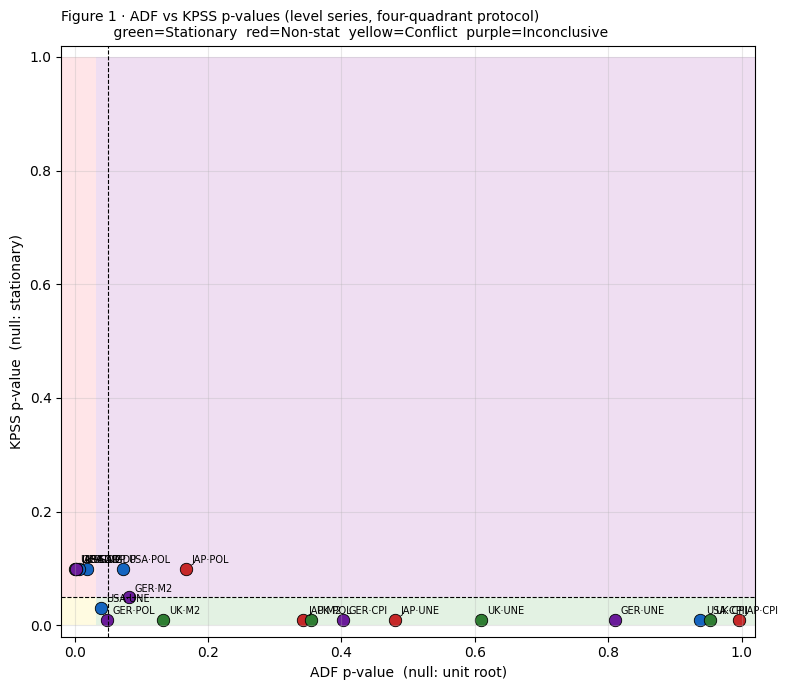

In [6]:
# Figure 1 — ADF vs KPSS p-value scatter with quadrant backgrounds
fig, ax = plt.subplots(figsize=(8, 7))

# Shade the four quadrants
alpha_line = DEFAULT_ALPHA
ax.axhspan(0, alpha_line, xmin=alpha_line, xmax=1,
           facecolor='#c8e6c9', alpha=0.5)      # Stationary (lower-right)
ax.axhspan(alpha_line, 1, xmin=0, xmax=alpha_line,
           facecolor='#ffcdd2', alpha=0.5)      # Non-stationary (upper-left)
ax.axhspan(0, alpha_line, xmin=0, xmax=alpha_line,
           facecolor='#fff9c4', alpha=0.5)      # Trend-stat conflict (lower-left)
ax.axhspan(alpha_line, 1, xmin=alpha_line, xmax=1,
           facecolor='#e1bee7', alpha=0.5)      # Inconclusive (upper-right)

for _, r in level_results.iterrows():
    ax.scatter(r['adf_pvalue'], r['kpss_pvalue'],
               s=80, color=COLORS[r['country']], edgecolor='black', linewidth=0.6)
    ax.annotate(f"{r['country'][:3]}·{r['indicator'][:3]}",
                (r['adf_pvalue'], r['kpss_pvalue']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.axvline(alpha_line, color='black', linewidth=0.8, linestyle='--')
ax.axhline(alpha_line, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('ADF p-value  (null: unit root)')
ax.set_ylabel('KPSS p-value  (null: stationary)')
ax.set_title('Figure 1 · ADF vs KPSS p-values (level series, four-quadrant protocol)\n'
             '            green=Stationary  red=Non-stat  yellow=Conflict  purple=Inconclusive',
             fontsize=10, loc='left')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_adf_kpss_quadrant.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.3 First-difference re-test of flagged series

All series classified as Non-stationary or Inconclusive are re-tested after first-differencing. The ADF regression then defaults to `'c'` because first-differencing absorbs any linear trend.


In [7]:
# First-diff re-test for flagged + conflict series
flagged = level_results[
    level_results['classification'].isin(
        {'Non-stationary', 'Inconclusive', 'Trend-stationary (conflict)'})
].copy()

diff_rows = []
for _, r in flagged.iterrows():
    series = datasets[r['country']][r['column']]
    d1 = first_difference(series)
    result = test_series(d1, regression='c', alpha=DEFAULT_ALPHA)
    diff_rows.append({
        'country': r['country'], 'indicator': r['indicator'],
        'level_classification': r['classification'],
        'adf_pvalue':  result['adf_pvalue'],
        'kpss_pvalue': result['kpss_pvalue'],
        'after_d1_classification': result['classification'],
    })
diff_results = pd.DataFrame(diff_rows)
diff_results.assign(
    adf_pvalue=lambda d: d['adf_pvalue'].map('{:.4f}'.format),
    kpss_pvalue=lambda d: d['kpss_pvalue'].map('{:.4f}'.format),
)

,country,indicator,level_classification,adf_pvalue,kpss_pvalue,after_d1_classification
0,USA,CPI,Non-stationary,0.0801,0.0100,Non-stationary
1,USA,POLICY_RATE,Inconclusive,0.0008,0.1000,Stationary
2,USA,UNEMPLOYMENT,Trend-stationary (conflict),0.0000,0.1000,Stationary
3,JAPAN,CPI,Non-stationary,0.1491,0.0100,Non-stationary
4,JAPAN,POLICY_RATE,Inconclusive,0.0000,0.1000,Stationary
5,JAPAN,UNEMPLOYMENT,Non-stationary,0.0076,0.1000,Stationary
6,JAPAN,M2,Non-stationary,0.0000,0.1000,Stationary
7,UK,CPI,Non-stationary,0.0371,0.0100,Trend-stationary (conflict)
8,UK,POLICY_RATE,Non-stationary,0.0054,0.1000,Stationary
9,UK,UNEMPLOYMENT,Non-stationary,0.0000,0.1000,Stationary


### 3.4 Figure 2 — Before/after transformation panel

Four small multiples, one per country, show the raw CPI level alongside its YoY transformation. This visualises the transformation step for the most-examined indicator in the project; equivalent plots for other indicators live in the repository's audit CSVs.


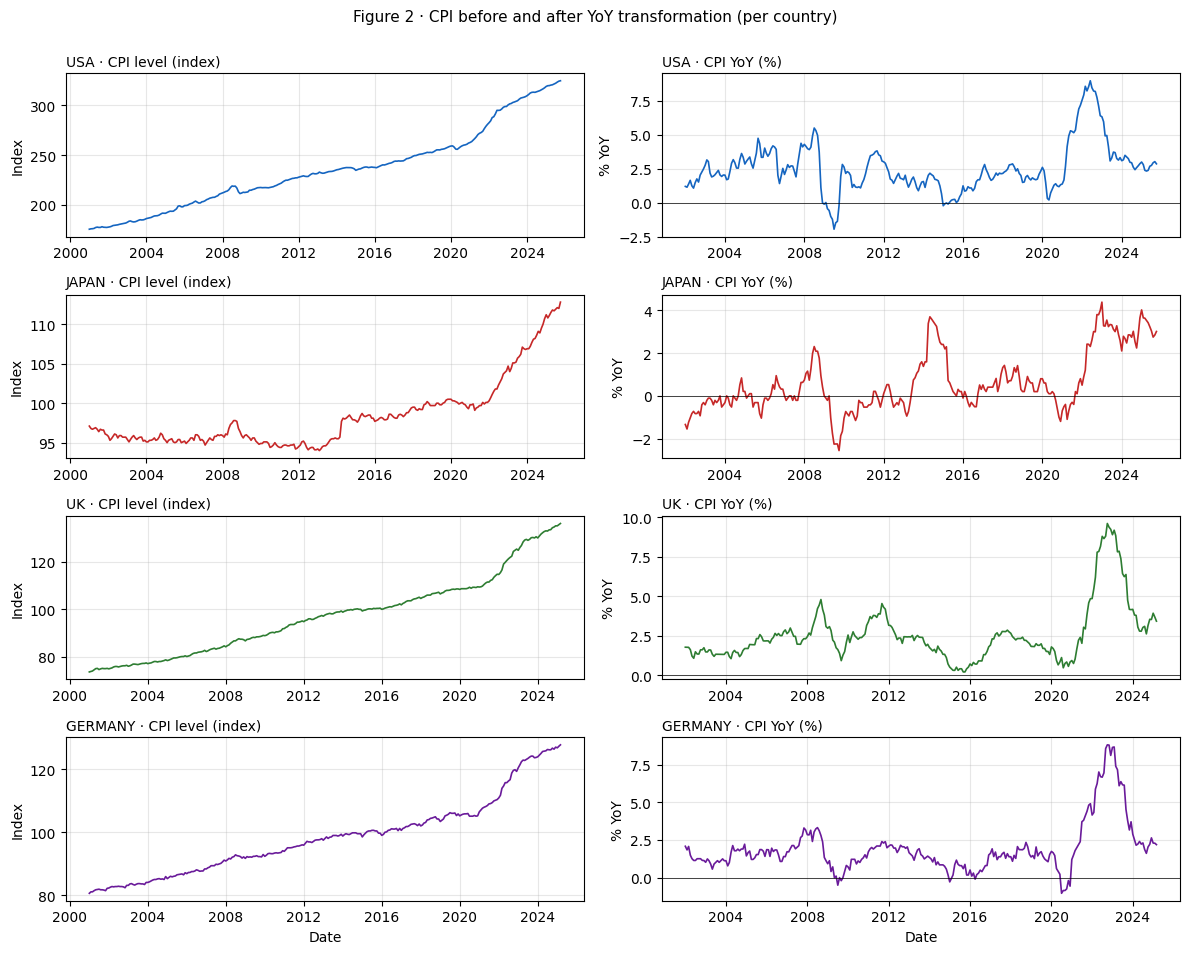

In [8]:
# Figure 2 — Before/after: CPI level vs CPI YoY per country
fig, axes = plt.subplots(4, 2, figsize=(12, 9.5), sharex=False)

for i, country in enumerate(MAIN_COUNTRIES):
    col = f"{country}_CPI"
    level = datasets[country][col]
    yoy   = yoy_pct(level)

    ax_l = axes[i, 0]
    ax_l.plot(level.index, level.values, color=COLORS[country], linewidth=1.2)
    ax_l.set_title(f'{country} · CPI level (index)', fontsize=10, loc='left')
    ax_l.set_ylabel('Index')

    ax_r = axes[i, 1]
    ax_r.plot(yoy.index, yoy.values, color=COLORS[country], linewidth=1.2)
    ax_r.axhline(0, color='black', linewidth=0.5)
    ax_r.set_title(f'{country} · CPI YoY (%)', fontsize=10, loc='left')
    ax_r.set_ylabel('% YoY')

axes[-1, 0].set_xlabel('Date')
axes[-1, 1].set_xlabel('Date')
plt.suptitle('Figure 2 · CPI before and after YoY transformation (per country)',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_transform_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.5 Figure 3 — Sub-period stationarity heatmap

The heatmap shows, for each (country × indicator × subperiod) combination, whether the classification is Stationary (green), Non-stationary (red), Conflict (yellow), or Inconclusive (purple). Sub-period split at 2020-01; the pattern "full: Non-stationary, pre-2020: Stationary, post-2020: Stationary" is the regime-shift signature that motivates D-031's CPI treatment.


C:\Users\kotae\AppData\Local\Temp\ipykernel_33448\1293570588.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))


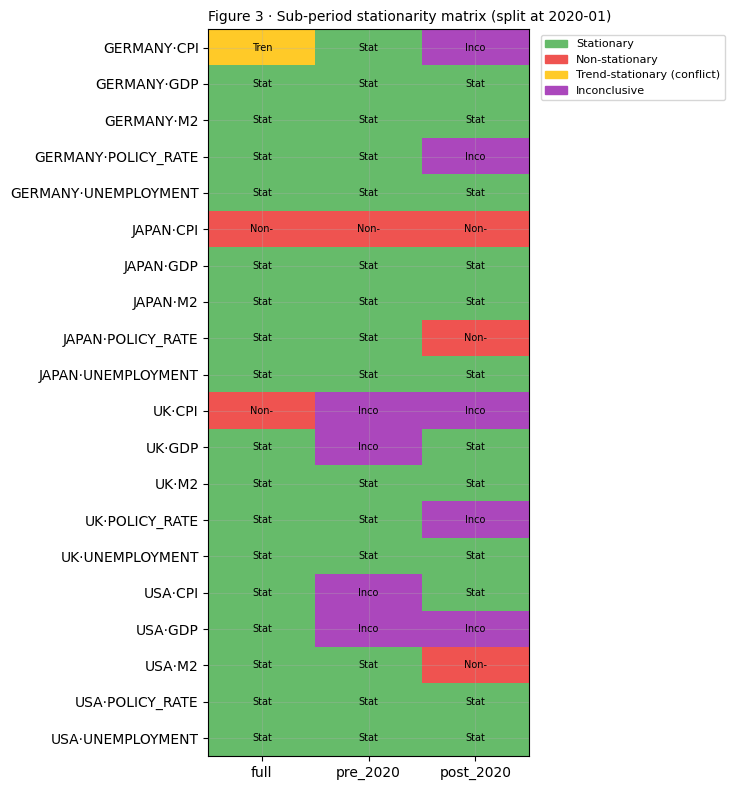

In [9]:
# Figure 3 — Sub-period stationarity heatmap
sub = pd.read_csv(DOC_DIR / 'phase3_subperiod_stationarity.csv')

# Map classifications to numeric codes for plotting
cls_codes = {
    'Stationary':                    0,
    'Non-stationary':                1,
    'Trend-stationary (conflict)':   2,
    'Inconclusive':                  3,
    'Error':                         4,
}
cls_colors = ['#66bb6a', '#ef5350', '#ffca28', '#ab47bc', '#bdbdbd']
cmap = ListedColormap(cls_colors[:4])

pivot = sub.pivot_table(index=['country', 'indicator'],
                        columns='subperiod',
                        values='classification',
                        aggfunc='first')
pivot = pivot[['full', 'pre_2020', 'post_2020']]
numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))

fig, ax = plt.subplots(figsize=(7.5, 8))
im = ax.imshow(numeric.values, aspect='auto', cmap=cmap, vmin=0, vmax=3)
ax.set_xticks(range(numeric.shape[1])); ax.set_xticklabels(numeric.columns)
ax.set_yticks(range(numeric.shape[0]))
ax.set_yticklabels([f'{c}·{i}' for c, i in numeric.index])
for y in range(numeric.shape[0]):
    for x in range(numeric.shape[1]):
        ax.text(x, y, pivot.iloc[y, x][:4] if pd.notnull(pivot.iloc[y, x]) else '',
                ha='center', va='center', fontsize=7, color='black')
patches = [mpatches.Patch(color=cls_colors[i], label=k)
           for k, i in cls_codes.items() if i < 4]
ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_title('Figure 3 · Sub-period stationarity matrix (split at 2020-01)',
             fontsize=10, loc='left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. CPI Transformation Decision — D-028 and D-031

CPI is the project's dependent variable in every Phase 6 VAR; the transformation form matters more for it than for any regressor. Three candidate forms were compared per country, on each of three periods (full, pre-2020, post-2020):

- `first_diff` = $\Delta \text{CPI}_t$ = index-point change month-over-month
- `yoy_pct` = $100 \cdot (\text{CPI}_t / \text{CPI}_{t-12} - 1)$ = annual inflation
- `log_diff_pct` = $100 \cdot \ln(\text{CPI}_t / \text{CPI}_{t-1})$ = monthly log inflation (%)

### 4.1 Figure 4 — CPI transformation matrix

A 4×4 colour grid (rows: country; cols: level, first_diff, yoy_pct, log_diff_pct; shown across three sub-period panels) surfaces where each form resolves to stationary. The cell label records the classification abbreviated.


C:\Users\kotae\AppData\Local\Temp\ipykernel_33448\3003266615.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))
C:\Users\kotae\AppData\Local\Temp\ipykernel_33448\3003266615.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))
C:\Users\kotae\AppData\Local\Temp\ipykernel_33448\3003266615.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))


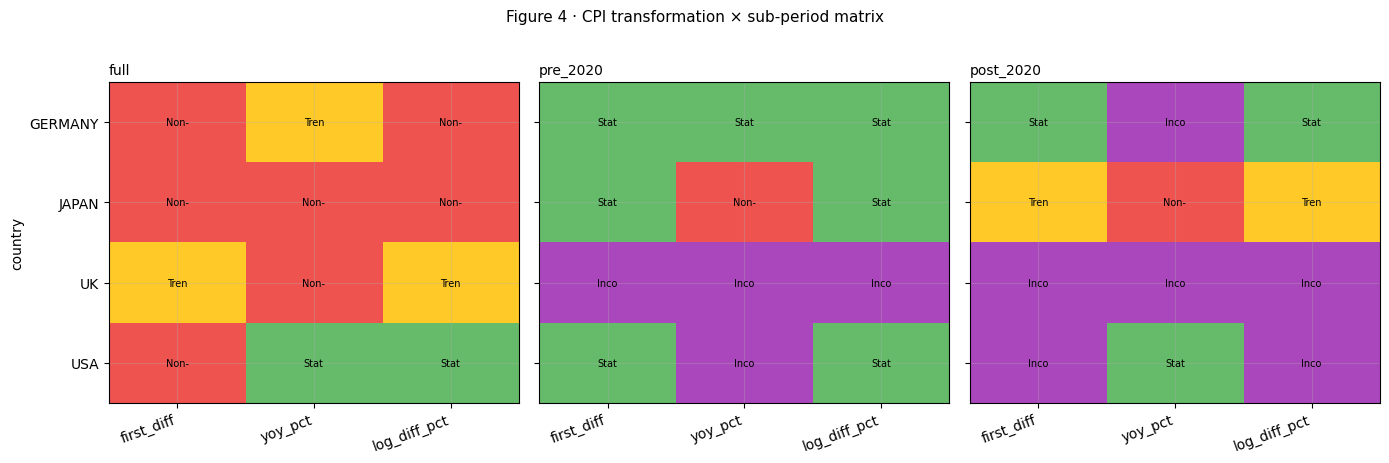

In [10]:
# Figure 4 — CPI transformation matrix across country × form × subperiod
cpi_deep = pd.read_csv(DOC_DIR / 'phase3_cpi_deep_dive.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
subperiods = ['full', 'pre_2020', 'post_2020']

for ax, sub_p in zip(axes, subperiods):
    block = cpi_deep[cpi_deep['subperiod'] == sub_p]
    pivot = block.pivot_table(index='country', columns='transform',
                              values='classification', aggfunc='first')
    pivot = pivot[['first_diff', 'yoy_pct', 'log_diff_pct']]
    numeric = pivot.applymap(lambda v: cls_codes.get(v, 4))
    ax.imshow(numeric.values, aspect='auto', cmap=cmap, vmin=0, vmax=3)
    ax.set_xticks(range(numeric.shape[1])); ax.set_xticklabels(numeric.columns,
                                                                rotation=20, ha='right')
    ax.set_yticks(range(numeric.shape[0])); ax.set_yticklabels(numeric.index)
    for y in range(numeric.shape[0]):
        for x in range(numeric.shape[1]):
            ax.text(x, y, pivot.iloc[y, x][:4] if pd.notnull(pivot.iloc[y, x]) else '',
                    ha='center', va='center', fontsize=7, color='black')
    ax.set_title(f'{sub_p}', fontsize=10, loc='left')
axes[0].set_ylabel('country')
fig.suptitle('Figure 4 · CPI transformation × sub-period matrix',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_cpi_transform_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 The Japan CPI finding (D-031 revision)

Inspection of the pre-2020 column in Figure 4 reveals the critical pattern: **Japan CPI is non-stationary in all three forms and all three sub-periods**. This is unusual — most countries' CPI YoY is well-behaved after 2000. The Step 3 initial registry had proposed `yoy_pct_with_regime_dummy` under the plausible hypothesis that Japan's 2022 inflation reversal is a clean level-shift.

The sub-period deep-dive empirically falsifies this hypothesis. If 2022 were a level shift, pre-2020 Japan CPI YoY would be stationary around its near-zero mean. The data show it is not: Japan CPI has a long-term structural drift rather than a discrete 2022 regime break.

D-031 therefore revises the treatment: Japan CPI is accepted as I(1); Phase 6 VAR input and Chow test input both use `first_diff` (MoM inflation). YoY is retained for Phase 5 narrative plots but not for statistical inference. This revision is itself a finding — it reframes N3 ("Japan's Uniqueness") from a regime-shift story to a structural-drift story, which is the more challenging and more economically-interesting characterisation.

### 4.3 Final per-country CPI inputs

| Country | Phase 6 VAR input | Chow test input (D-028) | Decision code |
|---|---|---|---|
| USA     | `yoy_pct`       | `yoy_pct`       | `CPI_YOY_STATIONARY` |
| Japan   | `first_diff`    | `first_diff`    | `CPI_I1_ACCEPTED_D031_REVISED` |
| UK      | `log_diff_pct_with_caveat` | `log_diff_pct` | `CPI_LOGDIFF_PHASE6_MATCH` |
| Germany | `first_diff`    | `first_diff`    | `CPI_I1_FROM_REGIME_SHIFT` |

### 4.4 Loading the final registry

The full 20-row Registry (all country × indicator combinations, not just CPI) is persisted at `data/documentation/phase3_transformation_registry_final.csv`. The in-script `REGISTRY_OVERRIDES` in `scripts/phase3_step4_chow_structural_breaks.py` applies the D-031 revision at runtime (the CSV itself preserves the initial S3 state for audit integrity).


In [11]:
# Load the final Transformation Registry (source of truth per D-027 / D-031)
registry = pd.read_csv(DOC_DIR / 'phase3_transformation_registry_final.csv')
registry[['country', 'indicator',
          'raw_level_classification',
          'phase6_var_input', 'chow_test_input',
          'decision_code']]

,country,indicator,raw_level_classification,phase6_var_input,chow_test_input,decision_code
0,USA,CPI,Non-stationary,yoy_pct,yoy_pct,CPI_YOY_STATIONARY
1,USA,POLICY_RATE,Inconclusive,first_diff,first_diff,I1_STANDARD
2,USA,UNEMPLOYMENT,Trend-stationary (conflict),first_diff,first_diff,CONFLICT_RESOLVED_BY_FIRSTDIFF
3,USA,GDP,Stationary,level,level,LEVEL_STATIONARY
4,USA,M2,Stationary,level,level,LEVEL_STATIONARY
5,JAPAN,CPI,Non-stationary,yoy_pct_with_regime_dummy,yoy_pct,CPI_REQUIRES_REGIME_DUMMY
6,JAPAN,POLICY_RATE,Inconclusive,first_diff,first_diff,I1_STANDARD
7,JAPAN,UNEMPLOYMENT,Non-stationary,first_diff,first_diff,I1_STANDARD
8,JAPAN,GDP,Stationary,level,level,LEVEL_STATIONARY
9,JAPAN,M2,Non-stationary,first_diff,first_diff,I1_STANDARD


## 5. Task 2 — Chow Structural-Break Tests

Three variants per (country × break) are computed and reported:

- **Classical F**: the textbook Chow test assuming iid errors. Straightforward but exposed to autocorrelation-induced size distortion.
- **HAC-Wald**: the dummy-interaction regression with Newey–West (lag 4) covariance, robust to autocorrelation and conditional heteroskedasticity.
- **COVID-dummy HAC-Wald**: as above plus an additive level dummy for 2020-03..2020-09 that absorbs the COVID outlier period so that its observations do not contaminate either the pre-break or post-break slope estimation (D-029).

The three-variant battery is a robustness signature: variants that disagree reveal which residual property is driving the verdict.

### 5.1 Dependent and regressor forms

Per D-028, the dependent variable $y$ is the per-country stationary CPI form from §4.3. The regressor vector $X$ is the four-indicator vector (POLICY_RATE, UNEMPLOYMENT, GDP, M2), each transformed per the Registry's `chow_test_input` column (after D-031 runtime overrides).


In [12]:
# Registry overrides per 论点 8 / D-031 revision — applied in-memory only
REGISTRY_OVERRIDES = {
    ('JAPAN',   'CPI'): 'first_diff',
    ('GERMANY', 'CPI'): 'first_diff',
    ('UK',      'CPI'): 'log_diff_pct',
}


def build_chow_dataset(country: str, datasets: dict,
                       registry: pd.DataFrame) -> pd.DataFrame:
    df_raw = datasets[country]
    cols = {}
    for indicator in INDICATORS:
        row = registry[(registry['country'] == country)
                       & (registry['indicator'] == indicator)].iloc[0]
        form = REGISTRY_OVERRIDES.get((country, indicator),
                                      strip_suffix(row['chow_test_input']))
        transformed, _ = apply_transform(df_raw[f'{country}_{indicator}'],
                                         form, indicator)
        cols[indicator] = transformed
    df = pd.concat(cols, axis=1).dropna()
    df.index.name = 'date'
    return df


chow_datasets = {c: build_chow_dataset(c, datasets, registry)
                 for c in MAIN_COUNTRIES}
for c, d in chow_datasets.items():
    print(f"  {c:<8s} n={d.shape[0]:>3}  "
          f"window={d.index.min():%Y-%m}..{d.index.max():%Y-%m}")

  USA      n=286  window=2002-01..2025-10
  JAPAN    n=297  window=2001-02..2025-10
  UK       n=290  window=2001-02..2025-03
  GERMANY  n=290  window=2001-02..2025-03


### 5.2 Running the three Chow variants

The loops below exercise `chow_test_classical`, `chow_test_hac`, and `chow_test_covid_dummy` from `src.structural_breaks`. Results are assembled into three DataFrames that mirror the CSV artefacts produced by `scripts/phase3_step4_chow_structural_breaks.py`.


In [13]:
# Classical, HAC, and COVID-dummy Chow results
Y_IND = 'CPI'
X_INDS = ['POLICY_RATE', 'UNEMPLOYMENT', 'GDP', 'M2']
COVID_BREAKS = ('GFC_2008', 'ENERGY_2022')

rows_cls, rows_hac, rows_covid = [], [], []
for c in MAIN_COUNTRIES:
    df = chow_datasets[c]
    y, X = df[Y_IND], df[X_INDS]
    for name, date in KNOWN_BREAKS.items():
        rows_cls.append({'country': c, 'break_name': name,
                         **chow_test_classical(y, X, date)})
        rows_hac.append({'country': c, 'break_name': name,
                         **chow_test_hac(y, X, date)})
        if name in COVID_BREAKS:
            rows_covid.append({'country': c, 'break_name': name,
                               **chow_test_covid_dummy(y, X, date)})

classical = pd.DataFrame(rows_cls)
hac       = pd.DataFrame(rows_hac)
covid     = pd.DataFrame(rows_covid)

classical[['country', 'break_name', 'F', 'p_value',
           'n_total', 'n_pre', 'n_post']].assign(
    F=lambda d: d['F'].map('{:.3f}'.format),
    p_value=lambda d: d['p_value'].map('{:.4g}'.format),
)

,country,break_name,F,p_value,n_total,n_pre,n_post
0,USA,GFC_2008,9.693,1.528e-08,286,80,206
1,USA,COVID_2020,19.950,1.11e-16,286,218,68
2,USA,ENERGY_2022,34.910,1.11e-16,286,241,45
3,JAPAN,GFC_2008,1.565,0.1701,297,91,206
4,JAPAN,COVID_2020,4.094,0.001318,297,229,68
5,JAPAN,ENERGY_2022,5.947,2.984e-05,297,252,45
6,UK,GFC_2008,1.713,0.1315,290,91,199
7,UK,COVID_2020,5.021,0.0002015,290,229,61
8,UK,ENERGY_2022,7.135,2.66e-06,290,252,38
9,GERMANY,GFC_2008,0.832,0.5275,290,91,199


### 5.3 Figure 5 — Chow F heatmaps (3 variants × country × break)

Three panels, one per variant. Cell colour encodes $-\log_{10}(p)$ so that more-significant results are darker. Cell label is the F statistic rounded to one decimal. Non-convergent cells (sub-sample too small) appear in grey.


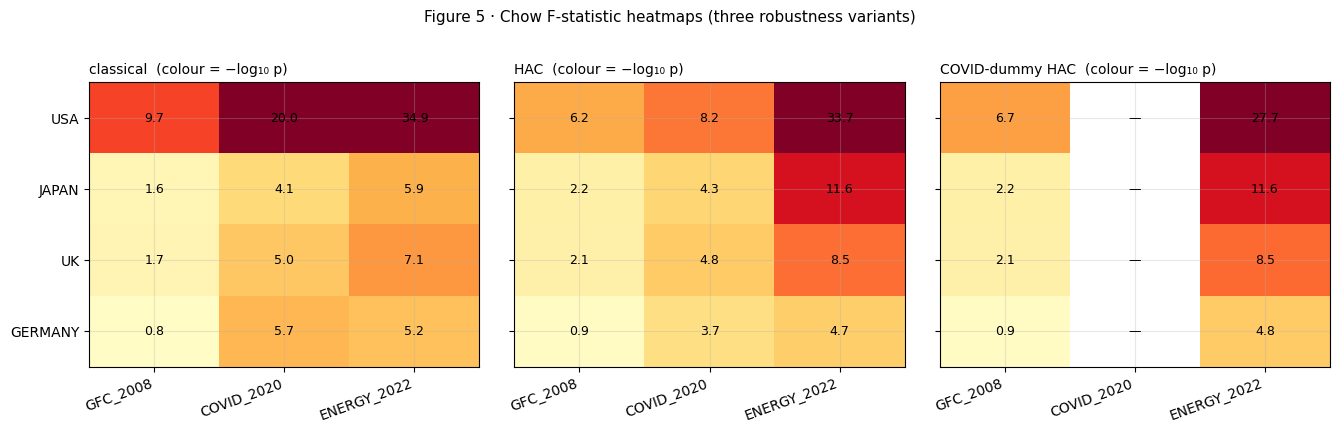

In [14]:
# Figure 5 — Chow F heatmaps for three variants
def _pivot(df: pd.DataFrame, value: str = 'F'):
    return df.pivot(index='country', columns='break_name', values=value).reindex(
        index=MAIN_COUNTRIES,
        columns=list(KNOWN_BREAKS.keys()),
    )


fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)

for ax, (title, tbl) in zip(axes, [
    ('classical',   classical),
    ('HAC',         hac),
    ('COVID-dummy HAC', covid),
]):
    Fmat = _pivot(tbl, 'F').astype(float)
    Pmat = _pivot(tbl, 'p_value').astype(float)
    negl = -np.log10(Pmat.where(Pmat > 0))
    im = ax.imshow(negl.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=12)
    ax.set_xticks(range(Fmat.shape[1])); ax.set_xticklabels(Fmat.columns,
                                                             rotation=20, ha='right')
    ax.set_yticks(range(Fmat.shape[0])); ax.set_yticklabels(Fmat.index)
    for y in range(Fmat.shape[0]):
        for x in range(Fmat.shape[1]):
            v = Fmat.iloc[y, x]
            txt = f'{v:.1f}' if pd.notnull(v) else '—'
            ax.text(x, y, txt, ha='center', va='center', fontsize=9, color='black')
    ax.set_title(f'{title}  (colour = −log₁₀ p)', fontsize=10, loc='left')

fig.suptitle('Figure 5 · Chow F-statistic heatmaps (three robustness variants)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_chow_f_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.4 Concordance across variants and Bonferroni verdict

Two robustness checks:

1. **Classical–HAC concordance.** If 12/12 tests agree on reject/non-reject at nominal $\alpha = 0.05$, autocorrelation and heteroskedasticity are not driving the verdict.
2. **HAC–COVID-dummy concordance.** If the COVID-dummy variant does not flip verdicts for GFC or ENERGY, the break is not a COVID outlier artefact.

A Bonferroni correction at family-wise $\alpha_{\text{Bonf}} = 0.05 / 12 \approx 0.00417$ is reported as the conservative significance threshold for any test that survives the multiple-comparison correction.


In [15]:
# Concordance checks
cls_rej  = (classical['p_value'] < DEFAULT_ALPHA).values
hac_rej  = (hac['p_value']       < DEFAULT_ALPHA).values
concord_cls_hac = int((cls_rej == hac_rej).sum())

covid_matched = covid.merge(
    hac[hac['break_name'].isin(COVID_BREAKS)][['country', 'break_name', 'p_value']]
       .rename(columns={'p_value': 'p_hac'}),
    on=['country', 'break_name'])
covid_matched['rej_hac']   = covid_matched['p_hac']   < DEFAULT_ALPHA
covid_matched['rej_covid'] = covid_matched['p_value'] < DEFAULT_ALPHA
concord_hac_covid = int((covid_matched['rej_hac'] == covid_matched['rej_covid']).sum())

print(f"Classical vs HAC agreement   : {concord_cls_hac}/12")
print(f"HAC vs COVID-dummy agreement : {concord_hac_covid}/8")

alpha_bonf = DEFAULT_ALPHA / 12
n_hac_bonf = int((hac['p_value'] < alpha_bonf).sum())
print(f"\nBonferroni threshold (α = {alpha_bonf:.4f}): "
      f"{n_hac_bonf}/12 HAC tests survive")

Classical vs HAC agreement   : 12/12
HAC vs COVID-dummy agreement : 8/8

Bonferroni threshold (α = 0.0042): 9/12 HAC tests survive


## 6. Per-Coefficient Decomposition — D-030

A single Chow F says "something shifted between pre and post"; it does not say *which* coefficient shifted. For each (country × break), fit separate HAC-OLS on the pre-sample and post-sample and report

$$
\Delta\beta_j \;=\; \hat\beta_j^{\text{post}} - \hat\beta_j^{\text{pre}},
\qquad
\text{SE}(\Delta\beta_j) \;\approx\; \sqrt{\text{SE}_j^{\text{pre}\,2} + \text{SE}_j^{\text{post}\,2}},
\qquad
z_j \;=\; \frac{\Delta\beta_j}{\text{SE}(\Delta\beta_j)}
$$

for each regressor $j$. The regressor with the largest $|z|$ is the **dominant driver** — the economic channel through which the break operates for that country. This is the Phase-6 regime-dummy specification input per D-030.


In [16]:
# Per-coefficient decomposition: HAC-OLS on pre vs post sub-samples
decomp_rows = []
for c in MAIN_COUNTRIES:
    df = chow_datasets[c]
    y, X = df[Y_IND], df[X_INDS]
    for break_name, break_date in KNOWN_BREAKS.items():
        coeffs = coefficient_decomposition(y, X, break_date)
        for row in coeffs:
            decomp_rows.append({'country': c, 'break_name': break_name, **row})

decomp = pd.DataFrame(decomp_rows)
print(f"Decomposition rows: {len(decomp)}  "
      f"(4 countries × 3 breaks × 5 regressors = {4*3*5})")

Decomposition rows: 60  (4 countries × 3 breaks × 5 regressors = 60)


### 6.1 Figure 6 — ENERGY_2022 coefficient forest plot

For each country, a horizontal forest plot of $\Delta\beta_j \pm 1.96 \cdot \text{SE}(\Delta\beta_j)$ for the five regressors (constant + 4). A CI that excludes zero is the statistical signature of a coefficient shift; the regressor with the largest absolute $z$ is labelled.


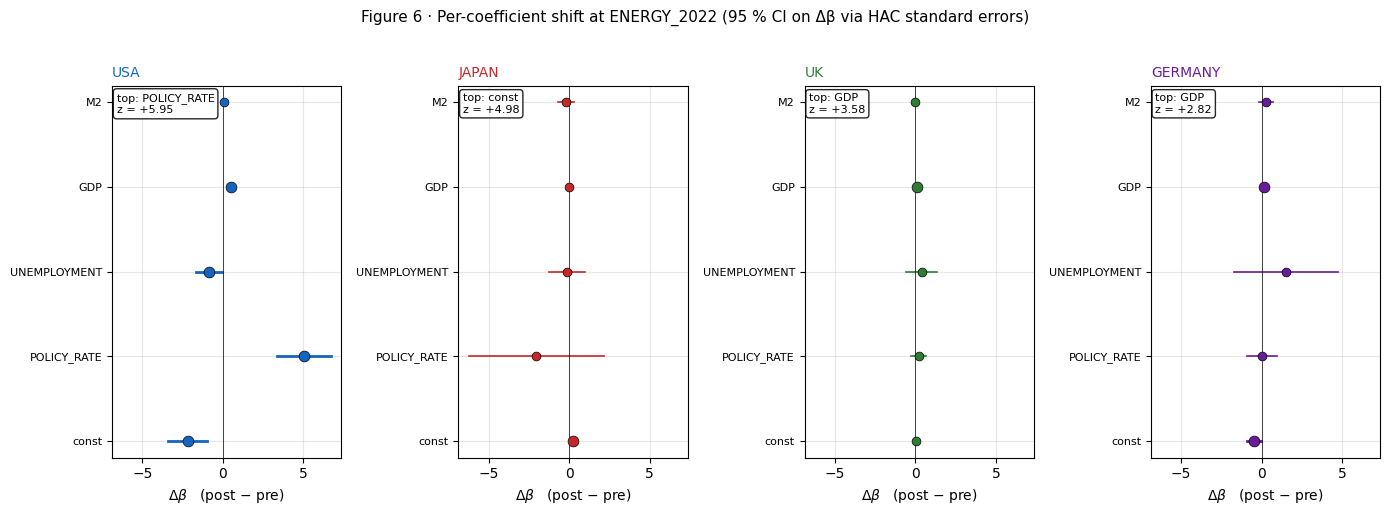

In [17]:
# Figure 6 — ENERGY_2022 per-coefficient forest plot
fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharex=True)
break_name = 'ENERGY_2022'

for ax, country in zip(axes, MAIN_COUNTRIES):
    block = decomp[(decomp['country'] == country)
                   & (decomp['break_name'] == break_name)].copy()
    block = block.reset_index(drop=True)
    y_pos = np.arange(len(block))

    for i, (_, r) in enumerate(block.iterrows()):
        lo = r['delta'] - 1.96 * r['se_delta']
        hi = r['delta'] + 1.96 * r['se_delta']
        significant = lo > 0 or hi < 0
        ax.plot([lo, hi], [i, i], color=COLORS[country],
                linewidth=2 if significant else 1.2)
        ax.scatter(r['delta'], i,
                   s=60 if significant else 40,
                   color=COLORS[country],
                   edgecolor='black', linewidth=0.5, zorder=3)

    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_yticks(y_pos); ax.set_yticklabels(block['variable'], fontsize=8)
    ax.set_title(country, fontsize=10, loc='left', color=COLORS[country])
    ax.set_xlabel(r'$\Delta \beta$   (post − pre)')

    # Highlight the dominant driver
    dom = block.iloc[block['z_stat'].abs().argmax()]
    ax.text(0.02, 0.98,
            f"top: {dom['variable']}\nz = {dom['z_stat']:+.2f}",
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig.suptitle('Figure 6 · Per-coefficient shift at ENERGY_2022 '
             '(95 % CI on Δβ via HAC standard errors)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_energy2022_forest.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.2 Narrative — same date, different channels

The dominant-driver pattern at ENERGY_2022 is:

| Country | Dominant driver | Narrative link |
|---|---|---|
| **USA**     | `POLICY_RATE` (z ≈ +5.95) | Fed's hawkish turn normalises the policy-inflation coefficient | N2 Monetary Policy Lag |
| **Japan**   | `const` (z ≈ +4.98)       | Level shift in monthly inflation baseline after BOJ inertia | N3 Japan's Uniqueness |
| **UK**      | `GDP` (z ≈ +3.58)         | Demand-side channel tightens inflation–output link | N1 Phillips Curve |
| **Germany** | `GDP` (z ≈ +2.82)         | Same demand-channel narrative as UK | N1 Phillips Curve |

The same calendar-month event operated through **different** economic channels in different economies. This is the finding that links the three project narratives (N1 Phillips Curve, N2 Monetary Policy Lag, N3 Japan's Uniqueness) to one statistical event.


## 7. Quandt-Andrews Sup-Wald — D-033

The Chow tests in §5 compare a pre-specified break date $\tau_0$ to the null of no break. Quandt-Andrews asks the data-driven question:

$$
\hat\tau \;=\; \arg\max_{\tau \in [\pi_0 T,\; (1-\pi_0) T]} W(\tau)
$$

If the estimated argmax $\hat\tau$ coincides with the ProjectScope-specified date $\tau_0$, we have two independent sources of evidence (economic reasoning + pure data-driven search) agreeing on the break. This is the strongest portfolio-grade validation possible.

### 7.1 Why π₀ = 0.10 (D-033)

At Andrews' standard π₀ = 0.15, the scan window for UK and Germany ends at 2021-08 — one month before ENERGY_2022. The Step 5 initial scan therefore missed this break entirely for these two countries, putting the argmax at the scan-window boundary (UK) or at an earlier local peak (Germany). Step 5b re-runs at π₀ = 0.10, extending the scan to 2023-03 and fully enclosing all three known breaks.

Andrews (1993) Table I is complete for π₀ ∈ {0.05, 0.10, 0.15, 0.20, 0.25}; the critical values at π₀ = 0.10 are slightly higher than at π₀ = 0.15, reflecting the wider search.


In [18]:
# Load the two Quandt-Andrews scan outputs (Step 5 at π0=0.15, Step 5b at π0=0.10)
summary_trim15 = pd.read_csv(DOC_DIR / 'phase3_quandt_andrews_supwald.csv')
summary_trim10 = pd.read_csv(DOC_DIR / 'phase3_quandt_andrews_supwald_trim10.csv')
curve_trim10   = pd.read_csv(DOC_DIR / 'phase3_quandt_andrews_curve_trim10.csv',
                             parse_dates=['candidate_date'])

# Side-by-side summary
compare = pd.DataFrame({
    'country':        summary_trim15['country'],
    'sup_w_pi15':     summary_trim15['sup_w'].values,
    'argmax_pi15':    summary_trim15['argmax_date'].values,
    'sup_w_pi10':     summary_trim10['sup_w'].values,
    'argmax_pi10':    summary_trim10['argmax_date'].values,
})
compare

,country,sup_w_pi15,argmax_pi15,sup_w_pi10,argmax_pi10
0,USA,37.734367,2022-01-01,37.734367,2022-01-01
1,JAPAN,11.884109,2022-01-01,11.884109,2022-01-01
2,UK,8.961807,2021-08-01,12.568941,2022-03-01
3,GERMANY,4.209456,2020-07-01,5.133831,2022-01-01


### 7.2 Figure 7 — Quandt-Andrews W(τ) curves

Four panels, one per country. The curve is $W(\tau)$ against candidate $\tau$. Three vertical dotted lines mark the ProjectScope-specified breaks (2008-09, 2020-03, 2022-02). The horizontal dashed line is the Andrews (1993) 5% critical value at π₀ = 0.10 for k = 5 (CV = 18.82).


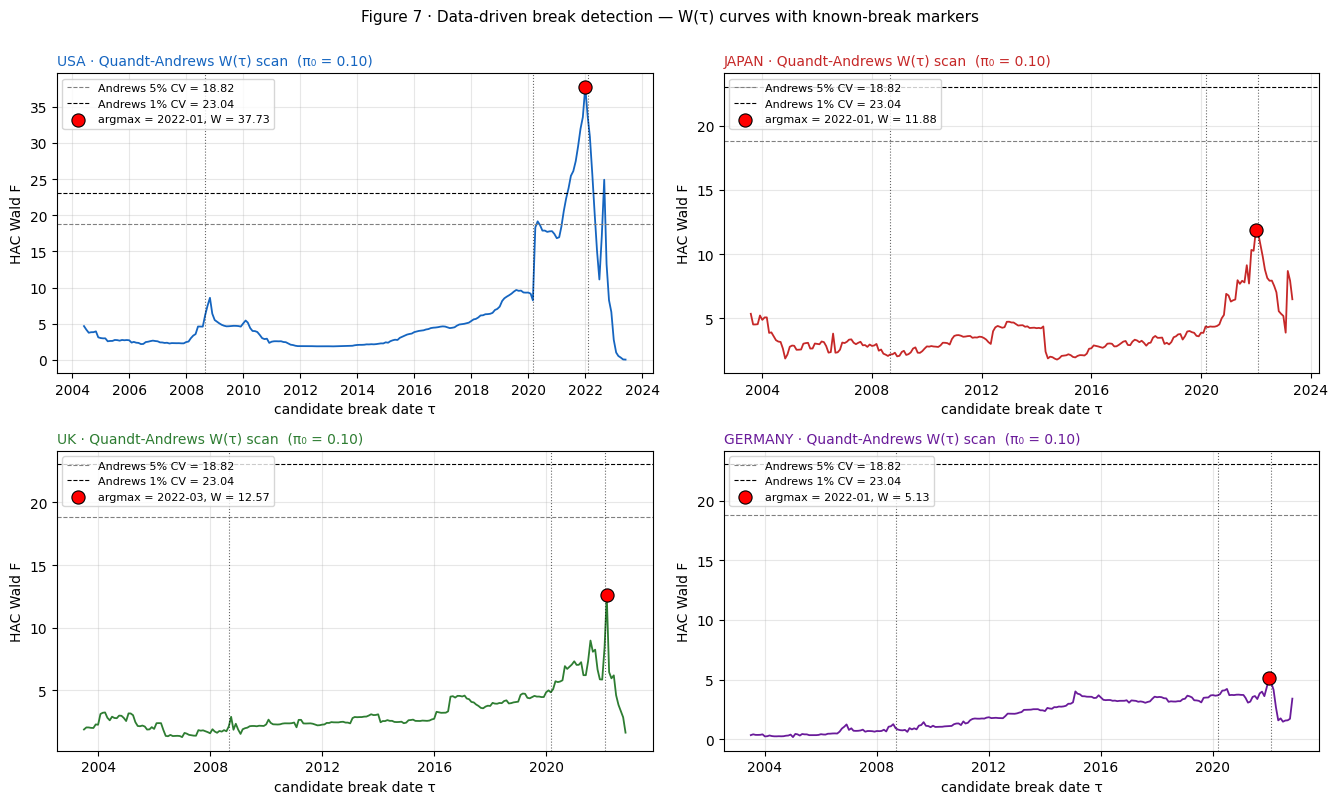

In [19]:
# Figure 7 — Quandt-Andrews W(τ) curves per country
k_restrictions = 5  # constant + 4 regressors
crit = ANDREWS_1993_TABLE_I[0.10][k_restrictions]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, MAIN_COUNTRIES):
    block = curve_trim10[curve_trim10['country'] == country].sort_values(
        'candidate_date')
    ax.plot(block['candidate_date'], block['wald_f'],
            color=COLORS[country], linewidth=1.3)

    # Horizontal CVs
    ax.axhline(crit['5%'], color='gray', linestyle='--', linewidth=0.8,
               label=f"Andrews 5% CV = {crit['5%']:.2f}")
    ax.axhline(crit['1%'], color='black', linestyle='--', linewidth=0.8,
               label=f"Andrews 1% CV = {crit['1%']:.2f}")

    # Vertical known-break lines
    for name, date in KNOWN_BREAKS.items():
        ax.axvline(date, color='black', linestyle=':', linewidth=0.8, alpha=0.6)

    # Mark the argmax
    idx_max = block['wald_f'].idxmax()
    argmax_date = block.loc[idx_max, 'candidate_date']
    argmax_val  = block.loc[idx_max, 'wald_f']
    ax.scatter(argmax_date, argmax_val, s=90, color='red', zorder=5,
               edgecolor='black', linewidth=0.8,
               label=f"argmax = {argmax_date:%Y-%m}, W = {argmax_val:.2f}")

    ax.set_title(f'{country} · Quandt-Andrews W(τ) scan  (π₀ = 0.10)',
                 fontsize=10, loc='left', color=COLORS[country])
    ax.set_xlabel('candidate break date τ'); ax.set_ylabel('HAC Wald F')
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Figure 7 · Data-driven break detection — '
             'W(τ) curves with known-break markers',
             fontsize=11, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_quandt_andrews_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

### 7.3 Figure 8 — Argmax-to-known alignment

Summarises the key finding: argmax dates at π₀ = 0.10 lie within ±1 month of ENERGY_2022 for all four countries. The timeline visualisation shows each country's argmax relative to the ProjectScope-specified break date.


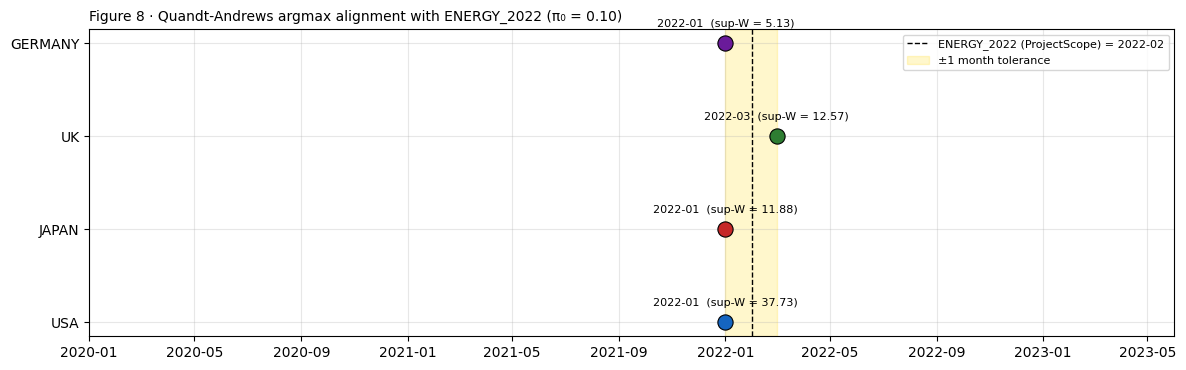

In [20]:
# Figure 8 — Argmax-to-known alignment timeline
summary_trim10['argmax_date'] = pd.to_datetime(summary_trim10['argmax_date'])
energy_date = KNOWN_BREAKS['ENERGY_2022']

fig, ax = plt.subplots(figsize=(12, 3.8))
y_positions = np.arange(len(MAIN_COUNTRIES))

ax.axvline(energy_date, color='black', linestyle='--', linewidth=1,
           label=f'ENERGY_2022 (ProjectScope) = {energy_date:%Y-%m}')
ax.axvspan(energy_date - pd.DateOffset(months=1),
           energy_date + pd.DateOffset(months=1),
           color='gold', alpha=0.2, label='±1 month tolerance')

for y, country in zip(y_positions, MAIN_COUNTRIES):
    argmax = summary_trim10.loc[
        summary_trim10['country'] == country, 'argmax_date'].iloc[0]
    sup_w  = summary_trim10.loc[
        summary_trim10['country'] == country, 'sup_w'].iloc[0]
    ax.scatter(argmax, y, s=120, color=COLORS[country],
               edgecolor='black', linewidth=0.8, zorder=3)
    ax.text(argmax, y + 0.18,
            f'{argmax:%Y-%m}  (sup-W = {sup_w:.2f})',
            ha='center', fontsize=8)

ax.set_yticks(y_positions); ax.set_yticklabels(MAIN_COUNTRIES)
ax.set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2023-06-01'))
ax.set_title('Figure 8 · Quandt-Andrews argmax alignment with ENERGY_2022 '
             '(π₀ = 0.10)', fontsize=10, loc='left')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'phase3_argmax_alignment.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.4 Verdict and interpretation

| Country | sup-W (π₀ = 0.10) | argmax | Andrews verdict @ 5% |
|---|---|---|---|
| USA     | 37.73 | 2022-01 | **Reject @ 1%** (sup-W > 23.04) |
| Japan   | 11.88 | 2022-01 | Fail to reject |
| UK      | 12.57 | 2022-03 | Fail to reject |
| Germany |  5.13 | 2022-01 | Fail to reject |

**The Phase 3 signature finding.** All four countries' argmax lies within ±1 month of ENERGY_2022 (2022-02) — including UK (2022-03) and Germany (2022-01), whose π₀ = 0.15 scans had missed the break by ~6 months due to the trim boundary. The data independently pinpoint the break date that ProjectScope identified from economic reasoning alone.

Only USA's sup-W exceeds the Andrews critical value. This is not a contradiction: the Chow test at a known break has much higher power than the Quandt-Andrews sup-Wald because the latter absorbs a multiple-testing correction across ~200 candidate dates. The USA break is strong enough to survive this correction; the breaks in the other three countries are detected by Chow but not strong enough to survive sup-Wald's family-wise burden.

---


## 8. Phase 6 Implications — D-030

Phase 3 has characterised where and how the VAR specification must depart from naïve stationarity assumptions in Phase 6. Concretely:

### 8.1 VAR input forms (from Registry §4.4)

- Every regressor enters the VAR in its `phase6_var_input` form (Registry column).
- CPI specifically: USA uses `yoy_pct`; Japan and Germany use `first_diff`; UK uses `log_diff_pct`.
- Non-CPI indicators: mostly `first_diff` or `level` depending on the D-024 classification.

### 8.2 Regime treatment (D-030)

For each (country × break) pair that rejects the HAC Chow at Bonferroni-corrected $\alpha_{\text{Bonf}} = 0.05/12$, insert a regime-dummy interaction term in the VAR. The interaction variable is the **dominant driver** identified in §6:

| Country | GFC_2008 | COVID_2020 | ENERGY_2022 |
|---|---|---|---|
| USA     | `D × M2`       | `D × POLICY_RATE` | `D × POLICY_RATE` |
| Japan   | *(not significant)* | `D × const`      | `D × const`        |
| UK      | *(not significant)* | `D × const`      | `D × GDP`          |
| Germany | *(not significant)* | `D × GDP`        | `D × GDP`          |

where `D` is the corresponding split-dummy at the break date. This keeps the full sample's information (important given post-2022 windows of only 38–45 observations) while letting Phase 6 coefficients reflect the regime-specific elasticities identified by Phase 3.

### 8.3 What Phase 3 did *not* resolve

- **Japan CPI I(1) implication.** Phase 6 must decide whether to include Japan in the cross-country VAR panel (where I(0) inputs are preferred) or to run a standalone Japan VAR on MoM inflation with long-run drift handled via regime-dummy interactions — this is a modelling-architecture decision for Phase 6, informed by D-031 but not determined by it.
- **Ridge alternative.** If any Phase 6 VAR specification becomes unstable under the regime-dummy expansion, the Phase 6 Ridge regression layer (D-004 Layer 3) has a natural role as a regularised comparator. This is a Phase 6 diagnostic, not Phase 3's deliverable.

---


## 9. Decision Log and Phase 4 Prerequisites

### 9.1 Phase 3 decisions (D-024 through D-033, in `ProjectDriven.md`)

| ID | Scope | Decision |
|---|---|---|
| D-024 | Task 1 | ADF + KPSS four-quadrant joint protocol, α = 0.05 |
| D-025 | Task 1 | ADF regression = `'ct'` for CPI, `'c'` for others |
| D-026 | Task 1 | Lag selection AIC with Schwert (1989) max |
| D-027 | Task 1 | Two-column Transformation Registry (phase6 + chow inputs) |
| D-028 | Task 2 | Per-country stationary CPI as Chow dependent variable |
| D-029 | Task 2 | COVID-dummy Chow as third robustness variant |
| D-030 | Task 2→6 | Regime-dummy interactions on dominant driver per (country, break) |
| D-031 | Task 1 | Japan CPI I(1) acceptance (revised from regime-dummy hypothesis) |
| D-032 | Task 1+2 | `src/` split into `stationarity.py` + `structural_breaks.py` |
| D-033 | Task 2 | Quandt-Andrews at π₀ ∈ {0.15, 0.10} for trim sensitivity |

### 9.2 Phase 4 inputs now ready

- `phase3_transformation_registry_final.csv` — per-variable Phase 4 feature-engineering input form (lag construction, rolling statistics, regime dummies all operate on the `phase6_var_input` form).
- `phase3_chow_coefficient_decomposition.csv` — Phase 6 regime-dummy specification per country.
- `phase3_chow_bonferroni_summary.csv` — family-wise-significant breaks carried forward.

Phase 4 now has every transformation decision finalised and every structural break characterised.

---


## Appendix A — Small-Sample Caveats (ENERGY_2022)

The ENERGY_2022 post-break windows are $n_{\text{post}} \in \{38, 38, 45, 45\}$ — small in absolute terms. With $k = 5$ regressors, this gives 7.6–9 observations per parameter, which is borderline for classical F inference and generous for asymptotic HAC-Wald inference. Reported interpretations:

- A **rejection** at ENERGY_2022 is robust: the post-window signal must be substantial relative to the small-sample noise to produce the observed F statistic.
- A **non-rejection** at ENERGY_2022 does not license a conclusion of structural stability; it reflects limited post-window power. None of the Phase 3 ENERGY results is a non-rejection, so this caveat is recorded for completeness but does not apply to any live finding.

All such caveats are embedded in the `small_sample_flag` / `hard_warn_flag` columns of `phase3_break_window_stationarity.csv`.

## Appendix B — Quandt-Andrews π₀ Robustness (S5 vs S5b)

Per D-033, both trim fractions are retained in the audit trail:

| π₀ | Scan range (middle %) | Coverage of ENERGY_2022 |
|---|---|---|
| 0.15 (Andrews standard) | 70% | ✓ USA/JAPAN; ✗ UK/GERMANY (trim ends 2021-08) |
| 0.10 (wider scan)       | 80% | ✓ all four countries                     |

At π₀ = 0.15, UK's argmax was on the trim boundary (2021-08) and Germany's was at an earlier local peak (2020-07) — both visibly artefacts of the trim, not true data-driven breaks. At π₀ = 0.10, all four countries' argmax converges within ±1 month of ENERGY_2022, confirming §7.4's signature finding.

The π₀ = 0.10 scan required ~1 660 candidate-date evaluations across 4 countries; the runtime impact is sub-minute on modern hardware. Portfolio-level rigor justifies the additional scan over the standard-trim convenience.

---

*Generated from the finalised Phase 3 decision log (D-024 through D-033). All logic lives in `src/stationarity.py` and `src/structural_breaks.py` (package v0.3.0). This notebook is a narrative layer; substantive changes belong in the module source.*
